<a href="https://colab.research.google.com/github/mannduuu07-png/korea-fire-frequency-severity-analysis/blob/main/notebooks/02_temporal_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 - Temporal Analysis

Examines national-level trends over 2015-2024: annual fire counts,
casualties, property damage, and monthly seasonality.

In [1]:
import pandas as pd

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

df = pd.read_parquet('/content/drive/MyDrive/fire_data/processed/cleaned_fire_data.parquet')
print(df.shape)

Mounted at /content/drive
(405977, 20)


## Annual trend: first-3-year vs last-3-year average

Comparing 2015 vs 2024 alone is noisy (a single unusual year skews
the result). Using 3-year averages at each end is more robust.

In [2]:
yearly = df.groupby('연도').agg(
    화재건수=('연도', 'count'),
    사망자수=('사망', 'sum'),
    재산피해합계=('재산피해소계', 'sum'),  # unit: thousand KRW
).reset_index()

first3, last3 = yearly.iloc[:3], yearly.iloc[-3:]
print(yearly)
print(f"\nFire count change: {(last3['화재건수'].mean()/first3['화재건수'].mean()-1)*100:.1f}%")
print(f"Death count change: {(last3['사망자수'].mean()/first3['사망자수'].mean()-1)*100:.1f}%")
print(f"Property damage change: {(last3['재산피해합계'].mean()/first3['재산피해합계'].mean()-1)*100:.1f}% (nominal, thousand KRW)")

     연도   화재건수  사망자수      재산피해합계
0  2015  44435   253   433208573
1  2016  43413   306   420633780
2  2017  44178   345   506913578
3  2018  42338   369   559712389
4  2019  40103   285   858496234
5  2020  38659   365   600475432
6  2021  36267   276  1099124986
7  2022  40113   342  1210411421
8  2023  38857   283   952949714
9  2024  37614   308   783947430

Fire count change: -11.7%
Death count change: 3.2%
Property damage change: 116.6% (nominal, thousand KRW)


## Monthly seasonality

Average fire count by month, across all 10 years.

In [3]:
monthly_avg = df.groupby('월').size() / df['연도'].nunique()
print(monthly_avg)

월
1     3889.7
2     3732.1
3     4368.6
4     3658.0
5     3520.0
6     3134.0
7     2894.3
8     3069.0
9     2709.7
10    2937.7
11    3069.5
12    3615.1
dtype: float64


## STL decomposition and autocorrelation

Confirms the seasonality seen in the monthly averages above is a
genuine periodic pattern, not just an artifact of averaging across
years. Uses monthly fire counts as a proper 120-point time series
(2015-01 through 2024-12).

In [4]:
!pip install statsmodels -q

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# Build a proper monthly time series (not averaged across years)
monthly_ts = df.groupby(pd.PeriodIndex(df['화재발생년월일'], freq='M')).size()
monthly_ts.index = monthly_ts.index.to_timestamp()
monthly_ts = monthly_ts.asfreq('MS')  # ensure regular monthly frequency

print(monthly_ts.head())
print(f"\nLength: {len(monthly_ts)} months")

화재발생년월일
2015-01-01    3678
2015-02-01    3792
2015-03-01    6549
2015-04-01    3544
2015-05-01    4206
Freq: MS, dtype: int64

Length: 120 months


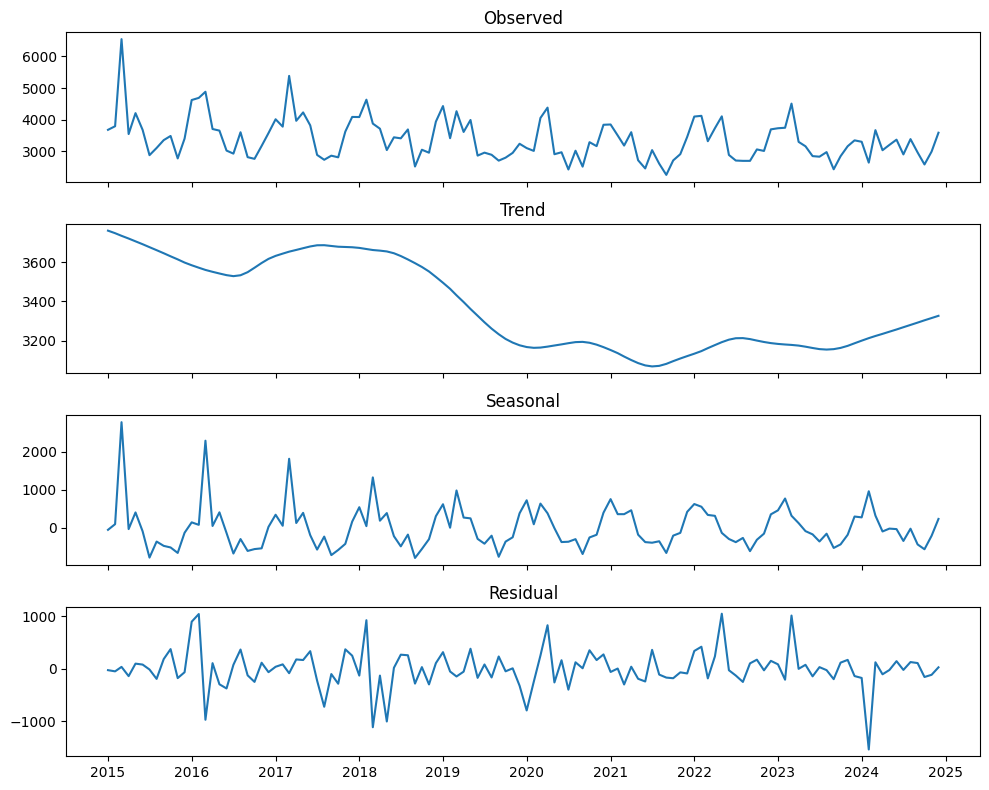

In [5]:
stl = STL(monthly_ts, period=12, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
axes[0].plot(monthly_ts); axes[0].set_title('Observed')
axes[1].plot(result.trend); axes[1].set_title('Trend')
axes[2].plot(result.seasonal); axes[2].set_title('Seasonal')
axes[3].plot(result.resid); axes[3].set_title('Residual')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fire_data/processed/stl_decomposition.png', dpi=150)
plt.show()

## Autocorrelation function (ACF)

A peak at lag=12 (and again at lag=24) confirms a genuine annual
cycle, not just noise in the year-by-year averages. Confirmed
statistically: ACF at lag=12 (ρ=0.49, 95% CI [0.20, 0.79]) and
lag=24 (ρ=0.46, 95% CI [0.07, 0.84]) are both significant at α=0.05.
Combined with the monthly averages above, which show March and
winter months as consistent peaks, this indicates a real, recurring
seasonal pattern in fire occurrence.

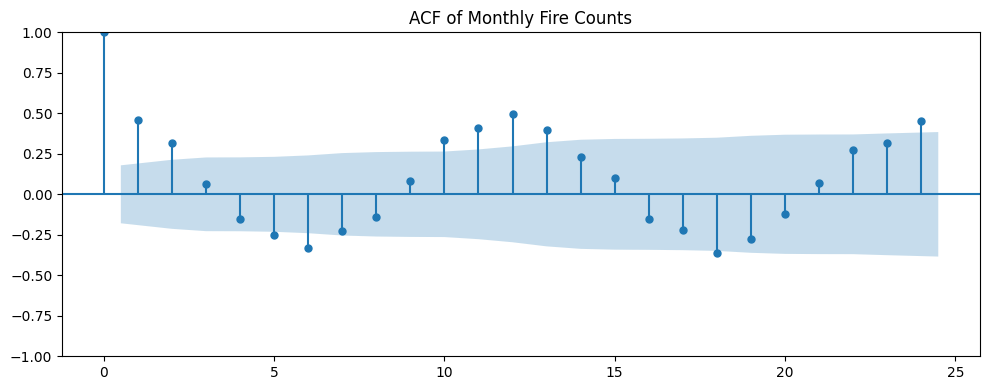

In [6]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(monthly_ts, lags=24, ax=ax)
plt.title('ACF of Monthly Fire Counts')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fire_data/processed/acf_plot.png', dpi=150)
plt.show()

In [7]:
import statsmodels.api as sm

acf_vals, confint = sm.tsa.acf(monthly_ts, nlags=24, alpha=0.05, fft=False)

for lag in [1, 12, 24]:
    lo, hi = confint[lag]
    significant = not (lo <= 0 <= hi)  # 0이 신뢰구간 밖에 있으면 유의미
    print(f"lag={lag}: acf={acf_vals[lag]:.3f}, 95% CI=[{lo:.3f}, {hi:.3f}], significant={significant}")

lag=1: acf=0.458, 95% CI=[0.279, 0.637], significant=True
lag=12: acf=0.494, 95% CI=[0.198, 0.790], significant=True
lag=24: acf=0.456, 95% CI=[0.071, 0.840], significant=True
